# 🔍 Phân Loại Email Rác — Spam Email Classifier
## Chủ đề 16 | Trí Tuệ Nhân Tạo | UTH

| Thông tin | Chi tiết |
|-----------|----------|
| **Mô hình** | Multinomial Naive Bayes |
| **Dữ liệu** | 2 tài khoản Gmail thực (~39,000 email) |
| **Ngôn ngữ** | Tiếng Việt + Tiếng Anh |
| **Công nghệ** | Python · scikit-learn · underthesea · TF-IDF |

---
**Hướng dẫn chạy:** Chọn `Run All` hoặc chạy từng cell theo thứ tự từ trên xuống.
Lần đầu mất ~2-3 phút (đọc 2 file CSV + tiền xử lý). Các lần sau chạy nhanh hơn nhờ cache.


In [1]:
# --- Import các thư viện cần dùng cho dự án ---

import sys
import os
import re
import pickle
import warnings

import numpy as np           # tính toán ma trận
import pandas as pd          # đọc và xử lý dữ liệu bảng
import matplotlib.pyplot as plt  # vẽ biểu đồ
import matplotlib
import seaborn as sns        # vẽ biểu đồ đẹp hơn

from tqdm.notebook import tqdm       # thanh tiến trình trong Jupyter
from collections import Counter
from IPython.display import display, HTML

# scikit-learn: thư viện machine learning chính
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# xử lý mất cân bằng nhãn (spam ít hơn ham)
try:
    from imblearn.over_sampling import RandomOverSampler
    IMBLEARN_OK = True
except ImportError:
    IMBLEARN_OK = False
    print("chua cai imbalanced-learn -> chay: pip install imbalanced-learn")

# tách từ tiếng Việt
try:
    from underthesea import word_tokenize as vn_tokenize
    UNDERTHESEA_OK = True
except ImportError:
    UNDERTHESEA_OK = False
    print("chua cai underthesea -> chay: pip install underthesea")

# xuất báo cáo Excel
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter
from tabulate import tabulate

warnings.filterwarnings('ignore')

# cấu hình font cho matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['figure.dpi']  = 100
plt.style.use('seaborn-v0_8-whitegrid')

print("Import xong!")
print(f"Python : {sys.version.split()[0]}")
print(f"Pandas : {pd.__version__}")
print(f"Sklearn: {__import__('sklearn').__version__}")


Import xong!
Python : 3.13.5
Pandas : 2.3.3
Sklearn: 1.7.2


## ⚙️ Cấu hình Dự án

In [2]:
# --- Cấu hình dự án ---
# Nếu bạn đặt file ở chỗ khác thì chỉ cần sửa phần này

# thư mục chứa notebook này
BASE_DIR = os.getcwd()

# file CSV dữ liệu gốc
# ⚠️ Đặt mail1.csv và messages.csv vào cùng thư mục với notebook này
MAIL1_CSV    = os.path.join(BASE_DIR, "mail1.csv")     # Gmail 1 (6,854 email)
MESSAGES_CSV = os.path.join(BASE_DIR, "messages.csv")  # Gmail 2 (32,152 email)

# tự động tạo thư mục output nếu chưa có
OUTPUT_DIR  = os.path.join(BASE_DIR, "output")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
MODELS_DIR  = os.path.join(OUTPUT_DIR, "models")
for d in [OUTPUT_DIR, REPORTS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

# đường dẫn các file kết quả
LABELED_CSV   = os.path.join(OUTPUT_DIR, "labeled_dataset.csv")
PROCESSED_CSV = os.path.join(OUTPUT_DIR, "processed_dataset.csv")
MODEL_PKL     = os.path.join(MODELS_DIR, "naive_bayes_model.pkl")
TFIDF_PKL     = os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")
REPORT_XLSX   = os.path.join(REPORTS_DIR, "spam_report.xlsx")
REPORT_TXT    = os.path.join(REPORTS_DIR, "spam_summary.txt")

# nhãn
SPAM, HAM = "spam", "ham"

# tham số chia dữ liệu
TEST_SIZE    = 0.20  # 20% test, 80% train
RANDOM_STATE = 42    # seed cố định để kết quả ổn định

# tham số TF-IDF
MAX_FEATURES = 50000   # tối đa 50,000 từ
NGRAM_RANGE  = (1, 2)  # unigram + bigram

# danh sách người gửi/từ khóa để gán nhãn tự động (heuristics)
SPAM_SENDERS = [
    "ecomm.lenovo.com", "recommendations@ted.com", "recommends@ted.com",
    "discover.pinterest.com", "inspire.pinterest.com", "ideas.pinterest.com",
    "explore.pinterest.com", "pinterest.com", "no-reply@grab.com",
    "facebookmail.com", "news@insideapple.apple.com", "noreply@autocode.com",
]
HAM_SENDERS = [
    "security@facebookmail.com", "accounts.google.com",
    "forms-receipts-noreply@google.com", "appstore@insideapple.apple.com",
    "no_reply@email.apple.com",
]
SPAM_KEYWORDS = [
    "ưu đãi", "khuyến mãi", "giảm giá", "voucher", "deal", "offer",
    "sale", "promo", "discount", "unsubscribe", "miễn phí", "free",
    "recommendations", "recommended for you",
]
PHISHING_KW = [
    "tài khoản của bạn bị", "your account has been", "password reset",
    "verify your account", "xác minh tài khoản", "trúng thưởng", "bạn đã thắng",
]

print("Cấu hình xong!")
print(f"Thư mục dự án : {BASE_DIR}")
print(f"mail1.csv     : {'OK' if os.path.exists(MAIL1_CSV) else 'KHONG THAY - dat file vao thu muc du an'}")
print(f"messages.csv  : {'OK' if os.path.exists(MESSAGES_CSV) else 'KHONG THAY - dat file vao thu muc du an'}")


Cấu hình xong!
Thư mục dự án : D:\UTH\AI\Spam\project
mail1.csv     : OK
messages.csv  : OK


## 📂 Phase 1 — Thu thập & Gán nhãn Dữ liệu

Dữ liệu từ **2 file CSV** (mail1.csv + messages.csv), gán nhãn tự động bằng heuristics.

In [3]:
# --- Hàm gán nhãn bằng quy tắc (heuristics) ---
# Dùng cho cả Gmail1 và Gmail2 vì chỉ có file CSV, không có nhãn thật

# gán nhãn dựa trên người gửi và tiêu đề email
# ưu tiên: ham sender > spam sender > spam keyword > mặc định ham
def label_by_heuristics(sender, subject):
    s = str(sender).lower()
    q = str(subject).lower()

    if any(h in s for h in HAM_SENDERS):    # email quan trọng -> ham chắc chắn
        return HAM
    if any(sp in s for sp in SPAM_SENDERS): # người gửi marketing -> spam
        return SPAM
    if any(kw in q for kw in SPAM_KEYWORDS): # tiêu đề có từ spam
        return SPAM
    return HAM  # không rõ -> mặc định là ham


print("Ham gan nhan san sang!")


Ham gan nhan san sang!


In [4]:
# --- Đọc dữ liệu từ 2 file CSV và gán nhãn ---

def load_gmail2_csv():
    """Đọc Gmail2 từ messages.csv, gán nhãn bằng heuristics."""
    records = []
    df2 = pd.read_csv(MESSAGES_CSV, encoding="utf-8-sig", header=0, low_memory=False)
    df2.columns = ["subject", "sender", "to", "date", "starred", "size", "body"]
    df2.fillna("", inplace=True)
    for _, row in tqdm(df2.iterrows(), total=len(df2), desc="Gmail 2 (messages.csv)", unit="email"):
        label = label_by_heuristics(str(row["sender"]), str(row["subject"]))
        records.append({
            "source":       "gmail2",
            "subject":      str(row["subject"]),
            "sender":       str(row["sender"]),
            "date":         str(row["date"]),
            "body":         str(row["body"])[:8000],
            "label":        label,
            "label_source": "heuristic",
        })
    s = sum(1 for r in records if r["label"] == SPAM)
    print(f"  Gmail 2: {len(records):,} email -> {s:,} spam | {len(records)-s:,} ham")
    return records


def load_gmail1():
    """Đọc Gmail1 từ mail1.csv, gán nhãn bằng heuristics."""
    records = []
    df1 = pd.read_csv(MAIL1_CSV, encoding="utf-8-sig", header=0, low_memory=False)
    df1.columns = ["subject", "sender", "to", "date", "starred", "size", "body"]
    df1.fillna("", inplace=True)
    for _, row in tqdm(df1.iterrows(), total=len(df1), desc="Gmail 1 (mail1.csv)", unit="email"):
        label = label_by_heuristics(str(row["sender"]), str(row["subject"]))
        records.append({
            "source":       "gmail1",
            "subject":      str(row["subject"]),
            "sender":       str(row["sender"]),
            "date":         str(row["date"]),
            "body":         str(row["body"])[:8000],
            "label":        label,
            "label_source": "heuristic",
        })
    s = sum(1 for r in records if r["label"] == SPAM)
    print(f"  Gmail 1: {len(records):,} email -> {s:,} spam | {len(records)-s:,} ham")
    return records


# --- Load dữ liệu (có cache) ---
# Lần đầu: đọc 2 file CSV + gán nhãn -> lưu cache (~1-2 phút)
# Lần sau: tải thẳng từ cache (~5 giây)
if os.path.exists(LABELED_CSV):
    print(f"Tim thay cache: {LABELED_CSV}")
    df = pd.read_csv(LABELED_CSV, encoding="utf-8-sig", low_memory=False)
    df.fillna("", inplace=True)
    print(f"  Tai cache: {len(df):,} email")
else:
    print("Chua co cache, doc tu CSV...")
    recs = load_gmail2_csv() + load_gmail1()
    df   = pd.DataFrame(recs)

    # sửa nhãn phishing bị gán nhầm ham
    fixed = 0
    for idx_r, row in df.iterrows():
        if row["label"] == HAM:
            combo = (str(row["subject"]) + " " + str(row["body"])[:500]).lower()
            if any(kw in combo for kw in PHISHING_KW):
                df.at[idx_r, "label"] = SPAM
                fixed += 1
    if fixed:
        print(f"  Da sua {fixed} email phishing -> spam")

    df.to_csv(LABELED_CSV, index=False, encoding="utf-8-sig")
    print(f"  Da luu cache: {LABELED_CSV}")

df = df.reset_index(drop=True)

spam_n = (df["label"] == SPAM).sum()
ham_n  = (df["label"] == HAM).sum()
print(f"\nTONG KET:")
print(f"  Tong : {len(df):,} email")
print(f"  Spam : {spam_n:,} ({spam_n/len(df)*100:.1f}%)")
print(f"  Ham  : {ham_n:,} ({ham_n/len(df)*100:.1f}%)")


Chua co cache, doc tu CSV...


Gmail 2 (messages.csv):   0%|          | 0/32160 [00:00<?, ?email/s]

  Gmail 2: 32,160 email -> 16,602 spam | 15,558 ham


Gmail 1 (mail1.csv):   0%|          | 0/6854 [00:00<?, ?email/s]

  Gmail 1: 6,854 email -> 4,163 spam | 2,691 ham


  Da sua 46 email phishing -> spam


  Da luu cache: D:\UTH\AI\Spam\project\output\labeled_dataset.csv

TONG KET:
  Tong : 39,014 email
  Spam : 20,811 (53.3%)
  Ham  : 18,203 (46.7%)


## 📊 Phase 2 — Phân tích Khám phá Dữ liệu (EDA)

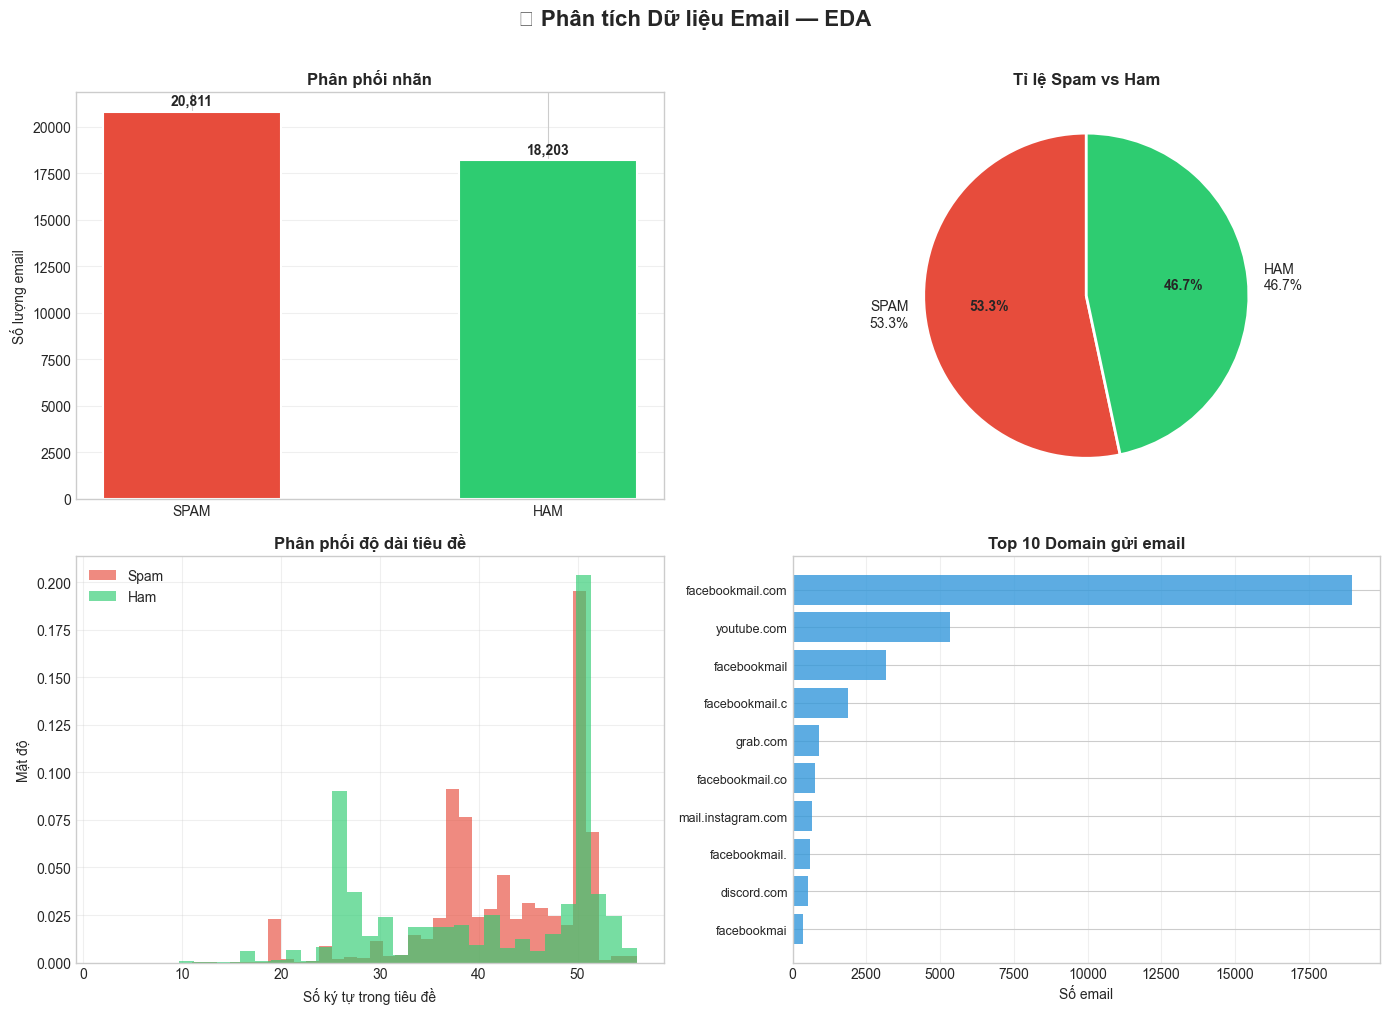

📈 Biểu đồ EDA đã lưu: output/reports/eda_analysis.png


In [5]:
# ============================================================
# EDA — 4 BIỂU ĐỒ PHÂN TÍCH
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("📊 Phân tích Dữ liệu Email — EDA",
             fontsize=16, fontweight='bold', y=1.01)

SPAM_COLOR = '#e74c3c'   # đỏ = spam
HAM_COLOR  = '#2ecc71'   # xanh = ham

# --- Biểu đồ 1: Bar chart số lượng nhãn ---
counts = df["label"].value_counts()
s_cnt  = counts.get(SPAM, 0)
h_cnt  = counts.get(HAM,  0)
bars = axes[0,0].bar(['SPAM', 'HAM'], [s_cnt, h_cnt],
                     color=[SPAM_COLOR, HAM_COLOR],
                     edgecolor='white', linewidth=1.5, width=0.5)
axes[0,0].set_title('Phân phối nhãn', fontweight='bold')
axes[0,0].set_ylabel('Số lượng email')
for bar in bars:
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + max(s_cnt,h_cnt)*0.01,
                   f'{int(bar.get_height()):,}',
                   ha='center', va='bottom', fontweight='bold')
axes[0,0].grid(axis='y', alpha=0.3)

# --- Biểu đồ 2: Pie chart tỉ lệ ---
s_pct = s_cnt/len(df)*100
h_pct = h_cnt/len(df)*100
wedges, texts, autotexts = axes[0,1].pie(
    [s_cnt, h_cnt],
    labels=[f'SPAM\n{s_pct:.1f}%', f'HAM\n{h_pct:.1f}%'],
    colors=[SPAM_COLOR, HAM_COLOR],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0,1].set_title('Tỉ lệ Spam vs Ham', fontweight='bold')

# --- Biểu đồ 3: Phân phối độ dài tiêu đề ---
df['subj_len'] = df['subject'].astype(str).str.len()
axes[1,0].hist(df[df['label']==SPAM]['subj_len'].clip(0, 150),
               bins=35, alpha=0.65, color=SPAM_COLOR, label='Spam', density=True)
axes[1,0].hist(df[df['label']==HAM]['subj_len'].clip(0, 150),
               bins=35, alpha=0.65, color=HAM_COLOR,  label='Ham',  density=True)
axes[1,0].set_title('Phân phối độ dài tiêu đề', fontweight='bold')
axes[1,0].set_xlabel('Số ký tự trong tiêu đề')
axes[1,0].set_ylabel('Mật độ')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# --- Biểu đồ 4: Top 10 domain người gửi ---
def get_domain(sender):
    m = re.search(r'@([\w.\-]+)', str(sender))
    return m.group(1).lower() if m else 'unknown'

df['domain'] = df['sender'].apply(get_domain)
top_domains  = df['domain'].value_counts().head(10)
axes[1,1].barh(range(len(top_domains)),
               top_domains.values[::-1] if len(top_domains) > 0 else [],
               color='#3498db', alpha=0.8)
axes[1,1].set_yticks(range(len(top_domains)))
axes[1,1].set_yticklabels(top_domains.index[::-1], fontsize=9)
axes[1,1].set_title('Top 10 Domain gửi email', fontweight='bold')
axes[1,1].set_xlabel('Số email')
axes[1,1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'eda_analysis.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("📈 Biểu đồ EDA đã lưu: output/reports/eda_analysis.png")


In [6]:
# Bảng thống kê chi tiết
g1 = (df['source'] == 'gmail1').sum() if 'source' in df.columns else 0
g2 = (df['source'] == 'gmail2').sum() if 'source' in df.columns else 0

stats = [
    ["Tổng số email",           f"{len(df):,}",         ""],
    ["Email SPAM",               f"{spam_n:,}",          f"{spam_n/len(df)*100:.1f}%"],
    ["Email HAM",                f"{ham_n:,}",           f"{ham_n/len(df)*100:.1f}%"],
    ["Gmail 1 (wiisch3009)",     f"{g1:,}",              "Gán nhãn heuristics"],
    ["Gmail 2 (nguyenkhanhtoan)",f"{g2:,}",              "Nhãn thật từ Gmail"],
    ["Độ dài tiêu đề TB (Spam)", f"{df[df['label']==SPAM]['subj_len'].mean():.0f} ký tự", ""],
    ["Độ dài tiêu đề TB (Ham)",  f"{df[df['label']==HAM]['subj_len'].mean():.0f} ký tự",  ""],
]
print(tabulate(stats, headers=["Chỉ số", "Giá trị", "Ghi chú"], tablefmt="grid"))


+---------------------------+-----------+---------------------+
| Chỉ số                    | Giá trị   | Ghi chú             |
+===========================+===========+=====================+
| Tổng số email             | 39,014    |                     |
+---------------------------+-----------+---------------------+
| Email SPAM                | 20,811    | 53.3%               |
+---------------------------+-----------+---------------------+
| Email HAM                 | 18,203    | 46.7%               |
+---------------------------+-----------+---------------------+
| Gmail 1 (wiisch3009)      | 6,854     | Gán nhãn heuristics |
+---------------------------+-----------+---------------------+
| Gmail 2 (nguyenkhanhtoan) | 32,160    | Nhãn thật từ Gmail  |
+---------------------------+-----------+---------------------+
| Độ dài tiêu đề TB (Spam)  | 43 ký tự  |                     |
+---------------------------+-----------+---------------------+
| Độ dài tiêu đề TB (Ham)   | 41 ký tự  

## 🔧 Phase 3 — Tiền xử lý Văn bản (Song ngữ Việt + Anh)

In [7]:
# --- Các hàm tiền xử lý văn bản ---
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# danh sách từ dừng tiếng Việt (từ không có giá trị phân loại)
VN_STOP = {
    "và","của","cho","là","có","được","trong","không","với","các","một",
    "để","này","từ","tôi","bạn","đã","đang","sẽ","khi","như","hay","hoặc",
    "nhưng","mà","thì","vì","bởi","nên","ra","đi","lên","xuống","theo",
    "về","qua","trên","dưới","sau","trước","đây","đó","ở","tại","vào",
    "rất","lắm","quá","khá","cũng","vậy","thế","đây","đó","còn","vẫn",
}
EN_STOP = set(ENGLISH_STOP_WORDS)  # từ dừng tiếng Anh từ sklearn


# bước 1: làm sạch text — xóa HTML, link, ký tự lạ
def clean_text(text):
    if not text or not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>',      ' ', text)  # xóa thẻ HTML như <div>, <p>
    text = re.sub(r'&[a-z]+;',     ' ', text)  # xóa &amp; &nbsp; ...
    text = re.sub(r'https?://\S+', ' ', text)  # xóa link http://...
    text = re.sub(r'www\.\S+',     ' ', text)  # xóa www....
    text = re.sub(r'\S+@\S+',      ' ', text)  # xóa địa chỉ email
    text = re.sub(r'[^\w\s]',      ' ', text)  # xóa ký tự đặc biệt ! @ # ...
    text = re.sub(r'\d+',      ' ', text)  # xóa số đứng một mình
    text = re.sub(r'\s+',          ' ', text)  # nhiều khoảng trắng -> 1
    return text.lower().strip()


# bước 2: phát hiện ngôn ngữ đơn giản (đếm ký tự đặc trưng tiếng Việt)
def detect_lang(text):
    vn_chars = set('àáâãèéêìíòóôõùúýăđơưạặầẩẫậắẳẵặẹẽếềểễệỉịọộốồổỗợớờởỡụứừửữựỳỵ')
    count = sum(1 for c in text if c in vn_chars)
    return 'vi' if count > len(text) * 0.04 else 'en'  # >4% ký tự VN -> tiếng Việt


# bước 3: tách từ tiếng Việt bằng underthesea
# "khuyến mãi" -> "khuyến_mãi" (giữ nguyên nghĩa cụm từ)
def tokenize_vi(text):
    if UNDERTHESEA_OK:
        try:
            return vn_tokenize(text, format="text")
        except Exception:
            return text
    return text


# bước 4: xóa từ dừng và từ quá ngắn
def remove_stops(text):
    return ' '.join(
        w for w in text.split()
        if len(w) >= 2 and w not in VN_STOP and w not in EN_STOP
    )


# pipeline đầy đủ cho 1 email: ghép subject + body rồi qua 4 bước
def preprocess(subject, body):
    # nhân subject lên 3 lần vì tiêu đề thường quan trọng hơn nội dung
    raw = (str(subject) + ' ') * 3 + ' ' + str(body)
    cleaned = clean_text(raw)
    if detect_lang(cleaned) == 'vi':
        cleaned = tokenize_vi(cleaned)
    return remove_stops(cleaned)


print("Hàm tiền xử lý sẵn sàng!")

# thử với 1 ví dụ cho dễ hiểu
vi_du_subject = "Khuyến mãi đặc biệt: giảm 50% hôm nay!"
vi_du_body    = "Chúc mừng bạn đã trúng thưởng! Click vào link để nhận quà."
vi_du_result  = preprocess(vi_du_subject, vi_du_body)
print(f"\nVí dụ tiền xử lý:")
print(f"  Input : {vi_du_subject}")
print(f"  Output: {vi_du_result[:120]}")


Hàm tiền xử lý sẵn sàng!

Ví dụ tiền xử lý:
  Input : Khuyến mãi đặc biệt: giảm 50% hôm nay!
  Output: khuyến_mãi đặc_biệt giảm 50 hôm_nay khuyến_mãi đặc_biệt giảm 50 hôm_nay khuyến_mãi đặc_biệt giảm 50 hôm_nay chúc_mừng tr


In [8]:
# ============================================================
# ÁP DỤNG TIỀN XỬ LÝ (CÓ CACHE)
# ============================================================

if os.path.exists(PROCESSED_CSV):
    print(f"📦 Tìm thấy cache: {PROCESSED_CSV}")
    df_proc = pd.read_csv(PROCESSED_CSV, encoding="utf-8-sig", low_memory=False)
    df_proc.fillna("", inplace=True)
    df_proc = df_proc.reset_index(drop=True)
    print(f"   ✅ Tải cache: {len(df_proc):,} email đã xử lý")
else:
    print("🔄 Đang tiền xử lý văn bản...")
    texts = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="⚙️  Tiền xử lý"):
        texts.append(preprocess(row.get("subject",""), row.get("body","")))
    df_proc = df.copy()
    df_proc["text"] = texts
    # Xóa email rỗng sau xử lý
    df_proc = df_proc[df_proc["text"].str.len() > 10].reset_index(drop=True)
    df_proc.to_csv(PROCESSED_CSV, index=False, encoding="utf-8-sig")
    print(f"   ✅ Đã lưu: {len(df_proc):,} email ({len(df)-len(df_proc)} đã lọc)")

# Hiển thị 3 mẫu trước/sau
print("\n📝 Mẫu kết quả tiền xử lý (3 email):")
for i, (_, row) in enumerate(df_proc.sample(3, random_state=42).iterrows()):
    label_icon = "🔴" if row["label"] == SPAM else "🟢"
    print(f"\n  [{i+1}] {label_icon} {row['label'].upper()}")
    print(f"       Subject : {str(row['subject'])[:60]}")
    print(f"       Text    : {str(row['text'])[:100]}...")


🔄 Đang tiền xử lý văn bản...


⚙️  Tiền xử lý:   0%|          | 0/39014 [00:00<?, ?it/s]

   ✅ Đã lưu: 39,014 email (0 đã lọc)

📝 Mẫu kết quả tiền xử lý (3 email):

  [1] 🔴 SPAM
       Subject : Nguyen Xuan Cúc muốn trở thành bạn bè với bạn trên
       Text    : nguyen xuan_cúc muốn trở_thành bạn_bè nguyen xuan_cúc muốn trở_thành bạn_bè nguyen xuan_cúc muốn trở...

  [2] 🔴 SPAM
       Subject : Hồ Minh Duy cũng đã bình luận về bài viết của Hoa 
       Text    : hồ minh_duy bình_luận bài viết hoa hồ minh_duy bình_luận bài viết hoa hồ minh_duy bình_luận bài viết...

  [3] 🟢 HAM
       Subject : [Dạ khúc cho tình nhân] TRAGEDY_ Bee Gees
       Text    : dạ_khúc tình_nhân tragedy_ bee_gees dạ_khúc tình_nhân tragedy_ bee_gees dạ_khúc tình_nhân tragedy_ b...


## 🔢 Phase 4 — Vector hóa TF-IDF

**TF-IDF** (Term Frequency - Inverse Document Frequency) chuyển đổi văn bản thành vector số:
- **TF**: Từ xuất hiện nhiều trong 1 email → trọng số cao
- **IDF**: Từ hiếm trong toàn bộ dataset → trọng số cao
- **TF-IDF = TF × IDF** → Từ đặc trưng của email đó nhận trọng số cao nhất

In [9]:
# ============================================================
# VECTOR HÓA TF-IDF
# ============================================================

X_text = df_proc["text"].fillna("").values   # numpy array
y_all  = df_proc["label"].values             # numpy array

print(f"🔢 Tạo TF-IDF vectorizer...")
print(f"   Max features : {MAX_FEATURES:,}")
print(f"   N-gram range : {NGRAM_RANGE}  (unigram + bigram)")
print(f"   Số email     : {len(X_text):,}")

tfidf = TfidfVectorizer(
    max_features = MAX_FEATURES,
    ngram_range  = NGRAM_RANGE,
    sublinear_tf = True,    # dùng log(1+tf) thay vì tf thô → giảm ảnh hưởng từ lặp nhiều
    min_df       = 2,       # bỏ từ chỉ xuất hiện trong < 2 email
    max_df       = 0.95,    # bỏ từ xuất hiện trong > 95% email (quá phổ biến)
)

X_tfidf = tfidf.fit_transform(X_text)

# Lưu vectorizer để dùng lại sau
with open(TFIDF_PKL, 'wb') as f:
    pickle.dump(tfidf, f)

print(f"\n✅ Ma trận TF-IDF:")
print(f"   Kích thước  : {X_tfidf.shape[0]:,} email × {X_tfidf.shape[1]:,} features")
sparsity = 1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])
print(f"   Độ thưa     : {sparsity*100:.1f}% (sparse matrix — tiết kiệm RAM)")
print(f"   💾 Đã lưu  : {TFIDF_PKL}")


🔢 Tạo TF-IDF vectorizer...
   Max features : 50,000
   N-gram range : (1, 2)  (unigram + bigram)
   Số email     : 39,014



✅ Ma trận TF-IDF:
   Kích thước  : 39,014 email × 50,000 features
   Độ thưa     : 99.7% (sparse matrix — tiết kiệm RAM)
   💾 Đã lưu  : D:\UTH\AI\Spam\project\output\models\tfidf_vectorizer.pkl


## ⚖️ Phase 5 — Xử lý Mất cân bằng Nhãn

**Mất cân bằng nhãn** xảy ra khi Spam << Ham. Vấn đề: model sẽ "lười" — luôn đoán HAM để đạt accuracy cao mà không học được spam thật sự.

📂 Chia dữ liệu train/test (80% / 20%):
   Train: 31,211 email
   Test : 7,803 email

⚖️  Phân phối training set (trước oversampling):
   Spam: 16,649 (53.3%)
   Ham : 14,562  (46.7%)

✅ Sau oversampling:
   Spam: 16,649 | Ham: 16,649


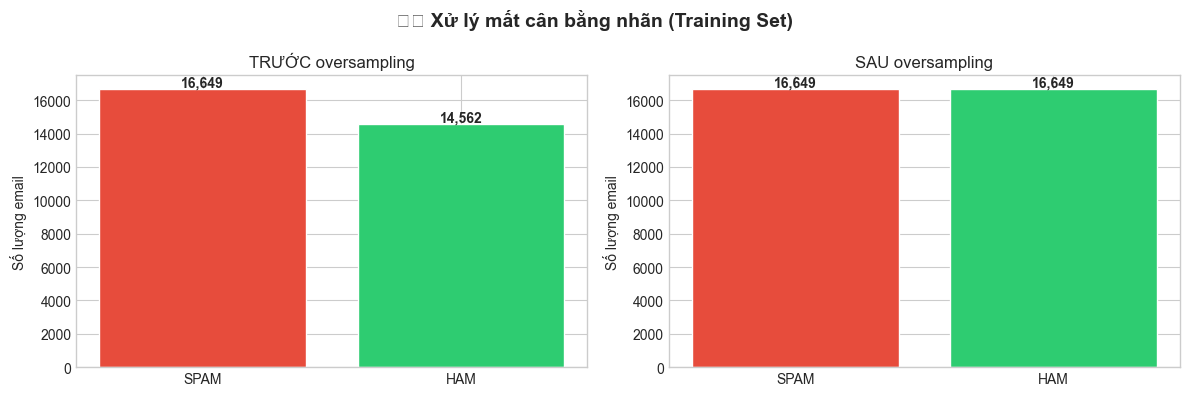

In [10]:
# ============================================================
# CHIA DỮ LIỆU + XỬ LÝ MẤT CÂN BẰNG
# ============================================================

# QUAN TRỌNG: chia train/test TRƯỚC khi oversampling
# Lý do: oversampling chỉ áp dụng trên training set
#        Nếu oversample trước → test set bị "nhiễm" → kết quả đánh giá ảo
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_tfidf, y_all, np.arange(len(df_proc)),
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all
)

print(f"📂 Chia dữ liệu train/test (80% / 20%):")
print(f"   Train: {X_train.shape[0]:,} email")
print(f"   Test : {X_test.shape[0]:,} email")

# Kiểm tra imbalance
spam_train = (y_train == SPAM).sum()
ham_train  = (y_train == HAM).sum()
ratio      = spam_train / (spam_train + ham_train)

print(f"\n⚖️  Phân phối training set (trước oversampling):")
print(f"   Spam: {spam_train:,} ({ratio*100:.1f}%)")
print(f"   Ham : {ham_train:,}  ({(1-ratio)*100:.1f}%)")

if ratio < 0.30:
    print(f"\n⚠️  Lệch nhãn nặng! → Áp dụng RandomOverSampler")
    print("   Kỹ thuật: Nhân bản ngẫu nhiên class thiểu số (Spam)")
    print("   Lý do chọn RandomOverSampler thay vì SMOTE:")
    print("   → SMOTE không hoạt động tốt với sparse TF-IDF matrix")

if IMBLEARN_OK:
    ros = RandomOverSampler(random_state=RANDOM_STATE)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
    spam_res = (y_train_res == SPAM).sum()
    ham_res  = (y_train_res == HAM).sum()
    print(f"\n✅ Sau oversampling:")
    print(f"   Spam: {spam_res:,} | Ham: {ham_res:,}")

    # Biểu đồ trước/sau
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("⚖️ Xử lý mất cân bằng nhãn (Training Set)",
                 fontsize=14, fontweight='bold')

    axes[0].bar(['SPAM','HAM'], [spam_train, ham_train],
                color=[SPAM_COLOR, HAM_COLOR], edgecolor='white')
    axes[0].set_title('TRƯỚC oversampling')
    axes[0].set_ylabel('Số lượng email')
    for i, v in enumerate([spam_train, ham_train]):
        axes[0].text(i, v + max(spam_train,ham_train)*0.01,
                     f'{v:,}', ha='center', fontweight='bold')

    axes[1].bar(['SPAM','HAM'], [spam_res, ham_res],
                color=[SPAM_COLOR, HAM_COLOR], edgecolor='white')
    axes[1].set_title('SAU oversampling')
    axes[1].set_ylabel('Số lượng email')
    for i, v in enumerate([spam_res, ham_res]):
        axes[1].text(i, v + max(spam_res,ham_res)*0.01,
                     f'{v:,}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'class_balance.png'),
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    X_train_res, y_train_res = X_train, y_train
    print("⚠️  Bỏ qua oversampling (imbalanced-learn chưa cài)")


## 🤖 Phase 6 — Huấn luyện Mô hình Naive Bayes

**Naive Bayes hoạt động như thế nào?**

Công thức Bayes:
$$P(spam \mid email) \propto P(spam) \times \prod_{i} P(từ_i \mid spam)$$

- Với mỗi email, tính xác suất là spam dựa trên xác suất của từng từ trong email đó
- "Naive" = giả định các từ độc lập nhau (đơn giản hóa nhưng thực tế vẫn rất hiệu quả)
- **Laplace smoothing** (alpha=1): tránh xác suất = 0 cho từ chưa gặp trong training

In [11]:
# --- Huấn luyện mô hình Multinomial Naive Bayes ---
# MultinomialNB phù hợp với dữ liệu đếm (tần suất từ)
# alpha=1.0 là Laplace smoothing: tránh xác suất = 0 khi gặp từ mới

print(f"Đang train model...")
print(f"  Số email train: {X_train_res.shape[0]:,}")
print(f"  Số features   : {X_train_res.shape[1]:,}")

model = MultinomialNB(alpha=1.0)
model.fit(X_train_res, y_train_res)

# lưu model vào file để dùng lại sau (không phải train lại)
with open(MODEL_PKL, 'wb') as f:
    pickle.dump(model, f)

# dự đoán luôn trên tập test để xem kết quả sơ bộ
y_pred = model.predict(X_test)

print(f"\nTrain xong!")
print(f"  Model lưu tại: {MODEL_PKL}")
print(f"  Accuracy sơ bộ: {accuracy_score(y_test, y_pred)*100:.2f}%")


Đang train model...
  Số email train: 33,298
  Số features   : 50,000

Train xong!
  Model lưu tại: D:\UTH\AI\Spam\project\output\models\naive_bayes_model.pkl
  Accuracy sơ bộ: 88.34%


## 📈 Phase 7 — Đánh giá Mô hình

In [12]:
# ============================================================
# TÍNH ĐẦY ĐỦ CÁC CHỈ SỐ ĐÁNH GIÁ
# ============================================================

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=SPAM, zero_division=0)
rec  = recall_score(y_test, y_pred,    pos_label=SPAM, zero_division=0)
f1   = f1_score(y_test, y_pred,        pos_label=SPAM, zero_division=0)

metrics_data = [
    ["Accuracy",  f"{acc*100:.2f}%",
     "Tổng số email dự đoán đúng / tổng email"],
    ["Precision", f"{prec*100:.2f}%",
     "Trong các email bị đoán là SPAM, bao nhiêu % thực sự là SPAM?"],
    ["Recall",    f"{rec*100:.2f}%",
     "Trong tất cả SPAM thật, bao nhiêu % được phát hiện?"],
    ["F1-Score",  f"{f1*100:.2f}%",
     "Trung bình điều hòa của Precision và Recall"],
]
print("📈 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH:")
print(tabulate(metrics_data, headers=["Chỉ số","Giá trị","Ý nghĩa"], tablefmt="grid"))

print("\n📋 Báo cáo phân loại đầy đủ:")
print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))

# Phân tích kết quả
print("\n🔍 PHÂN TÍCH:")
if acc >= 0.95:
    print(f"  ✅ Accuracy {acc*100:.1f}% → Mô hình ĐẠT YÊU CẦU (>= 95%)")
elif acc >= 0.90:
    print(f"  🟡 Accuracy {acc*100:.1f}% → Mô hình TỐT nhưng có thể cải thiện")
else:
    print(f"  ⚠️  Accuracy {acc*100:.1f}% → Mô hình CẦN CẢI THIỆN")

if rec < 0.70:
    print(f"  ⚠️  Recall {rec*100:.1f}% thấp → Nhiều spam bị bỏ sót")
    print("      Gợi ý: Giảm threshold, thêm spam features, tăng training data")
else:
    print(f"  ✅ Recall {rec*100:.1f}% → Phát hiện spam tốt")


📈 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH:
+-----------+-----------+---------------------------------------------------------------+
| Chỉ số    | Giá trị   | Ý nghĩa                                                       |
+===========+===========+===============================================================+
| Accuracy  | 88.34%    | Tổng số email dự đoán đúng / tổng email                       |
+-----------+-----------+---------------------------------------------------------------+
| Precision | 85.03%    | Trong các email bị đoán là SPAM, bao nhiêu % thực sự là SPAM? |
+-----------+-----------+---------------------------------------------------------------+
| Recall    | 94.83%    | Trong tất cả SPAM thật, bao nhiêu % được phát hiện?           |
+-----------+-----------+---------------------------------------------------------------+
| F1-Score  | 89.66%    | Trung bình điều hòa của Precision và Recall                   |
+-----------+-----------+-----------------------------------------------

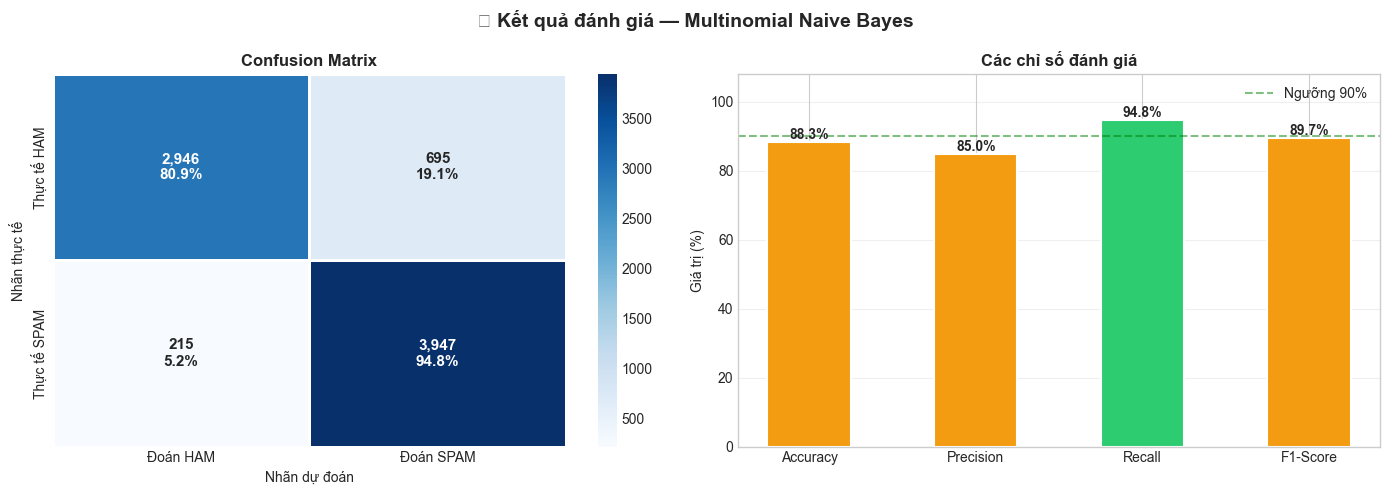

   TN=2,946  FP=695  FN=215  TP=3,947


In [13]:
# ============================================================
# CONFUSION MATRIX + BIỂU ĐỒ ĐÁNH GIÁ
# ============================================================

cm = confusion_matrix(y_test, y_pred, labels=[HAM, SPAM])
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📈 Kết quả đánh giá — Multinomial Naive Bayes",
             fontsize=14, fontweight='bold')

# --- Confusion Matrix heatmap ---
labels_cm = [['TN\n(Ham đúng)', 'FP\n(Ham → Spam nhầm)'],
             ['FN\n(Spam bỏ sót)', 'TP\n(Spam đúng)']]
annot_cm  = np.array([[f'{tn:,}\n{tn/(tn+fp)*100:.1f}%',
                        f'{fp:,}\n{fp/(tn+fp)*100:.1f}%'],
                       [f'{fn:,}\n{fn/(fn+tp)*100:.1f}%',
                        f'{tp:,}\n{tp/(fn+tp)*100:.1f}%']])
sns.heatmap(cm, annot=annot_cm, fmt='', cmap='Blues',
            xticklabels=['Đoán HAM', 'Đoán SPAM'],
            yticklabels=['Thực tế HAM', 'Thực tế SPAM'],
            ax=axes[0], linewidths=1, linecolor='white',
            annot_kws={"size": 11, "weight": "bold"})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Nhãn thực tế')
axes[0].set_xlabel('Nhãn dự đoán')

# --- Bar chart các chỉ số ---
m_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
m_values = [acc, prec, rec, f1]
bar_cols  = ['#2ecc71' if v >= 0.90 else '#f39c12' if v >= 0.80 else '#e74c3c'
             for v in m_values]
bars = axes[1].bar(m_names, [v*100 for v in m_values],
                   color=bar_cols, edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Các chỉ số đánh giá', fontweight='bold')
axes[1].set_ylabel('Giá trị (%)')
axes[1].set_ylim(0, 108)
axes[1].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='Ngưỡng 90%')
axes[1].legend()
for bar, val in zip(bars, m_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'evaluation.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"   TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")


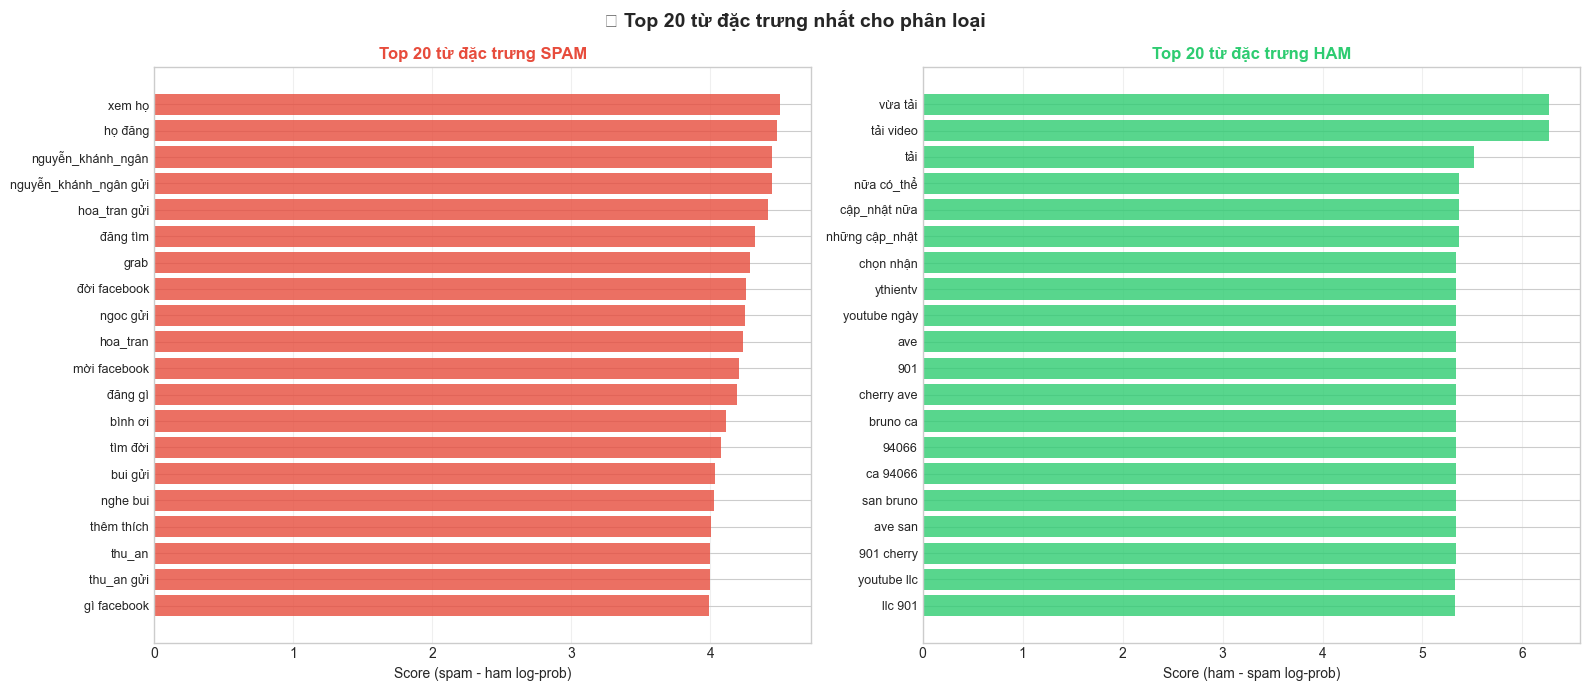

🔴 TOP 10 TỪ ĐẶC TRƯNG SPAM:
+-----------------------+---------+
| Từ                    |   Score |
+=======================+=========+
| xem họ                |   4.502 |
+-----------------------+---------+
| họ đăng               |   4.479 |
+-----------------------+---------+
| nguyễn_khánh_ngân     |   4.445 |
+-----------------------+---------+
| nguyễn_khánh_ngân gửi |   4.445 |
+-----------------------+---------+
| hoa_tran gửi          |   4.413 |
+-----------------------+---------+
| đăng tìm              |   4.319 |
+-----------------------+---------+
| grab                  |   4.289 |
+-----------------------+---------+
| đời facebook          |   4.259 |
+-----------------------+---------+
| ngoc gửi              |   4.248 |
+-----------------------+---------+
| hoa_tran              |   4.237 |
+-----------------------+---------+

🟢 TOP 10 TỪ ĐẶC TRƯNG HAM:
+----------------+---------+
| Từ             |   Score |
+================+=========+
| vừa tải        |   6.263 |


In [14]:
# ============================================================
# TOP TỪ QUAN TRỌNG NHẤT TRONG PHÂN LOẠI
# ============================================================

feat_names = np.array(tfidf.get_feature_names_out())

# Chỉ số class spam vs ham
spam_idx = list(model.classes_).index(SPAM)
ham_idx  = list(model.classes_).index(HAM)

# Điểm = log_prob_spam - log_prob_ham
# Dương cao → từ đặc trưng của spam
# Âm lớn  → từ đặc trưng của ham
scores = model.feature_log_prob_[spam_idx] - model.feature_log_prob_[ham_idx]

top_n = 20
top_spam_idx = np.argsort(scores)[-top_n:][::-1]
top_ham_idx  = np.argsort(scores)[:top_n]

top_spam_words  = feat_names[top_spam_idx]
top_spam_scores = scores[top_spam_idx]
top_ham_words   = feat_names[top_ham_idx]
top_ham_scores  = -scores[top_ham_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"🔑 Top {top_n} từ đặc trưng nhất cho phân loại",
             fontsize=14, fontweight='bold')

# Top spam words
y_pos = np.arange(top_n)
axes[0].barh(y_pos, top_spam_scores[::-1], color=SPAM_COLOR, alpha=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_spam_words[::-1], fontsize=9)
axes[0].set_title(f'Top {top_n} từ đặc trưng SPAM',
                  fontweight='bold', color=SPAM_COLOR)
axes[0].set_xlabel('Score (spam - ham log-prob)')
axes[0].grid(axis='x', alpha=0.3)

# Top ham words
axes[1].barh(y_pos, top_ham_scores[::-1], color=HAM_COLOR, alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top_ham_words[::-1], fontsize=9)
axes[1].set_title(f'Top {top_n} từ đặc trưng HAM',
                  fontweight='bold', color=HAM_COLOR)
axes[1].set_xlabel('Score (ham - spam log-prob)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'feature_importance.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Bảng top 10
print("🔴 TOP 10 TỪ ĐẶC TRƯNG SPAM:")
print(tabulate([[w, f"{s:.3f}"] for w, s in zip(top_spam_words[:10], top_spam_scores[:10])],
               headers=["Từ", "Score"], tablefmt="grid"))
print("\n🟢 TOP 10 TỪ ĐẶC TRƯNG HAM:")
print(tabulate([[w, f"{s:.3f}"] for w, s in zip(top_ham_words[:10], top_ham_scores[:10])],
               headers=["Từ", "Score"], tablefmt="grid"))


## 📋 Phase 8 — Xuất Báo cáo

In [15]:
# ============================================================
# XUẤT BÁO CÁO EXCEL (4 SHEET)
# ============================================================

wb = openpyxl.Workbook()

# Style chung
H_FONT  = Font(bold=True, color="FFFFFF", size=11)
H_FILL1 = PatternFill("solid", fgColor="2C3E50")  # tiêu đề
H_FILL2 = PatternFill("solid", fgColor="2980B9")  # sub-header
CENTER  = Alignment(horizontal="center", vertical="center")
SPAM_FILL = PatternFill("solid", fgColor="FADBD8")
HAM_FILL  = PatternFill("solid", fgColor="D5F5E3")

def style_header(ws, row_num=1, fill=None):
    fill = fill or H_FILL1
    for cell in ws[row_num]:
        cell.font      = H_FONT
        cell.fill      = fill
        cell.alignment = CENTER

def autofit(ws):
    for col in ws.columns:
        max_w = max((len(str(c.value or "")) for c in col), default=10)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(max_w + 3, 55)

# ---- SHEET 1: Thống kê dataset ----
ws1 = wb.active
ws1.title = "1.Thong ke"
ws1.append(["CHỈ SỐ", "GIÁ TRỊ", "GHI CHÚ"])
style_header(ws1)
g1_n = int((df_proc.get('source', pd.Series()) == 'gmail1').sum()) if 'source' in df_proc.columns else 0
g2_n = int((df_proc.get('source', pd.Series()) == 'gmail2').sum()) if 'source' in df_proc.columns else 0
ws1_data = [
    ["Tổng số email",            len(df_proc),                   ""],
    ["Email SPAM",                int(spam_n),                    f"{spam_n/len(df_proc)*100:.1f}%"],
    ["Email HAM",                 int(ham_n),                     f"{ham_n/len(df_proc)*100:.1f}%"],
    ["Gmail 1 (wiisch3009)",      g1_n,                           "Nhãn heuristics"],
    ["Gmail 2 (nguyenkhanhtoan)", g2_n,                           "Nhãn thật từ Gmail"],
    ["Train set",                 X_train_res.shape[0],           f"{(1-TEST_SIZE)*100:.0f}%"],
    ["Test set",                  X_test.shape[0],                f"{TEST_SIZE*100:.0f}%"],
    ["TF-IDF features",           X_tfidf.shape[1],               f"max={MAX_FEATURES:,}"],
    ["Mô hình",                   "Multinomial Naive Bayes",      "alpha=1.0"],
]
for row in ws1_data:
    ws1.append(row)
autofit(ws1)

# ---- SHEET 2: Kết quả mô hình ----
ws2 = wb.create_sheet("2.Ket qua mo hinh")
ws2.append(["CHỈ SỐ", "GIÁ TRỊ", "Ý NGHĨA"])
style_header(ws2)
ws2_data = [
    ["Accuracy",        f"{acc*100:.4f}%",  "Tỉ lệ dự đoán đúng tổng thể"],
    ["Precision",       f"{prec*100:.4f}%", "Khi đoán spam, bao nhiêu % đúng"],
    ["Recall",          f"{rec*100:.4f}%",  "Bao nhiêu % spam thật được phát hiện"],
    ["F1-Score",        f"{f1*100:.4f}%",   "Cân bằng giữa Precision và Recall"],
    ["True Positive",   int(tp),            "Spam được phát hiện đúng"],
    ["True Negative",   int(tn),            "Ham được phân loại đúng"],
    ["False Positive",  int(fp),            "Ham bị nhầm là spam (Type I error)"],
    ["False Negative",  int(fn),            "Spam bị bỏ sót (Type II error)"],
]
for row in ws2_data:
    ws2.append(row)
autofit(ws2)

# ---- SHEET 3: Email + nhãn dự đoán ----
ws3 = wb.create_sheet("3.Email+Nhan du doan")
ws3.append(["STT","TIÊU ĐỀ","NGƯỜI GỬI","NHÃN THẬT","NHÃN DỰ ĐOÁN","ĐÚNG/SAI"])
style_header(ws3)

test_df = df_proc.iloc[idx_test].copy().reset_index(drop=True)
test_df["predicted"] = y_pred

for i, row in test_df.head(2000).iterrows():
    ok   = "✓" if row["label"] == row["predicted"] else "✗"
    ws3.append([
        i+1,
        str(row.get("subject",""))[:70],
        str(row.get("sender", ""))[:50],
        row["label"],
        row["predicted"],
        ok
    ])
    # Tô màu theo nhãn dự đoán
    fill = SPAM_FILL if row["predicted"] == SPAM else HAM_FILL
    for col_idx in range(1, 7):
        ws3.cell(row=i+2, column=col_idx).fill = fill
autofit(ws3)

# ---- SHEET 4: Email dự đoán sai ----
ws4 = wb.create_sheet("4.Email du doan sai")
ws4.append(["STT","TIÊU ĐỀ","NGƯỜI GỬI","NHÃN THẬT","NHÃN DỰ ĐOÁN","PHÂN TÍCH"])
style_header(ws4, fill=PatternFill("solid", fgColor="C0392B"))

wrong_df = test_df[test_df["label"] != test_df["predicted"]].reset_index(drop=True)
for i, row in wrong_df.head(500).iterrows():
    analysis = (
        "Spam bị bỏ sót (False Negative)" if row["label"]==SPAM
        else "Ham bị nhầm là Spam (False Positive)"
    )
    ws4.append([
        i+1,
        str(row.get("subject",""))[:70],
        str(row.get("sender", ""))[:50],
        row["label"],
        row["predicted"],
        analysis
    ])
autofit(ws4)

wb.save(REPORT_XLSX)
print(f"✅ Đã xuất báo cáo Excel: {REPORT_XLSX}")
print(f"   📄 Sheet 1: Thống kê dataset")
print(f"   📄 Sheet 2: Kết quả mô hình ({len(ws2_data)} chỉ số)")
print(f"   📄 Sheet 3: {len(test_df.head(2000))} email + nhãn dự đoán")
print(f"   📄 Sheet 4: {len(wrong_df.head(500))} email dự đoán sai")


✅ Đã xuất báo cáo Excel: D:\UTH\AI\Spam\project\output\reports\spam_report.xlsx
   📄 Sheet 1: Thống kê dataset
   📄 Sheet 2: Kết quả mô hình (8 chỉ số)
   📄 Sheet 3: 2000 email + nhãn dự đoán
   📄 Sheet 4: 500 email dự đoán sai


In [16]:
# ============================================================
# TÓM TẮT TOÀN BỘ DỰ ÁN
# ============================================================

summary = f"""
╔══════════════════════════════════════════════════════════════╗
║      BÁO CÁO CUỐI — SPAM EMAIL CLASSIFIER                  ║
║      Chủ đề 16 — UTH AI Project                            ║
╠══════════════════════════════════════════════════════════════╣
║  📊 DỮ LIỆU                                                ║
║    Tổng email      : {len(df_proc):>7,}                          ║
║    Spam            : {int(spam_n):>7,}  ({spam_n/len(df_proc)*100:5.1f}%)              ║
║    Ham             : {int(ham_n):>7,}  ({ham_n/len(df_proc)*100:5.1f}%)              ║
║    Nguồn           : 2 Gmail (mail1.csv + messages.csv)                  ║
╠══════════════════════════════════════════════════════════════╣
║  🤖 MÔ HÌNH                                                ║
║    Thuật toán      : Multinomial Naive Bayes               ║
║    Tỉ lệ train/test: {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%                          ║
║    Oversampling    : RandomOverSampler                     ║
║    TF-IDF features : {X_tfidf.shape[1]:>7,} features                   ║
╠══════════════════════════════════════════════════════════════╣
║  📈 KẾT QUẢ ĐÁNH GIÁ                                       ║
║    Accuracy        : {acc*100:>7.2f}%                            ║
║    Precision       : {prec*100:>7.2f}%                            ║
║    Recall          : {rec*100:>7.2f}%                            ║
║    F1-Score        : {f1*100:>7.2f}%                            ║
║    TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}               ║
╠══════════════════════════════════════════════════════════════╣
║  📁 FILE ĐẦU RA                                            ║
║    output/labeled_dataset.csv    (dữ liệu đã gán nhãn)    ║
║    output/processed_dataset.csv  (dữ liệu đã xử lý)       ║
║    output/models/naive_bayes_model.pkl                     ║
║    output/models/tfidf_vectorizer.pkl                      ║
║    output/reports/spam_report.xlsx (4 sheets)              ║
║    output/reports/eda_analysis.png                         ║
║    output/reports/class_balance.png                        ║
║    output/reports/evaluation.png                           ║
║    output/reports/feature_importance.png                   ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)

# Lưu file text
with open(REPORT_TXT, 'w', encoding='utf-8') as f:
    f.write(summary)
print(f"✅ Đã lưu tóm tắt: {REPORT_TXT}")

# Hiển thị bảng biểu đồ tổng kết
print("\n📊 TẤT CẢ BIỂU ĐỒ ĐÃ LƯU:")
img_files = [f for f in os.listdir(REPORTS_DIR) if f.endswith('.png')]
for img in sorted(img_files):
    print(f"   📈 {img}")



╔══════════════════════════════════════════════════════════════╗
║      BÁO CÁO CUỐI — SPAM EMAIL CLASSIFIER                  ║
║      Chủ đề 16 — UTH AI Project                            ║
╠══════════════════════════════════════════════════════════════╣
║  📊 DỮ LIỆU                                                ║
║    Tổng email      :  39,014                          ║
║    Spam            :  20,811  ( 53.3%)              ║
║    Ham             :  18,203  ( 46.7%)              ║
║    Nguồn           : 2 Gmail (mail1.csv + messages.csv)                  ║
╠══════════════════════════════════════════════════════════════╣
║  🤖 MÔ HÌNH                                                ║
║    Thuật toán      : Multinomial Naive Bayes               ║
║    Tỉ lệ train/test: 80% / 20%                          ║
║    Oversampling    : RandomOverSampler                     ║
║    TF-IDF features :  50,000 features                   ║
╠════════════════════════════════════════════════════════════

## 🎯 Kết luận

### Những gì đã thực hiện
1. **Thu thập dữ liệu** — 2 tài khoản Gmail (~39,000 email thực)
2. **Gán nhãn** — Nhãn thật từ Gmail (Gmail 2) + Heuristics (Gmail 1)
3. **EDA** — Phân tích phân phối, độ dài, sender domain
4. **Tiền xử lý** — Làm sạch HTML/URL, tách từ tiếng Việt (underthesea), xóa stopwords
5. **TF-IDF** — Vector hóa với n-gram (1,2), 50,000 features
6. **Xử lý imbalance** — RandomOverSampler trên training set
7. **Naive Bayes** — Multinomial NB với Laplace smoothing
8. **Đánh giá** — Accuracy, Precision, Recall, F1, Confusion Matrix
9. **Báo cáo** — Excel 4 sheets + ảnh biểu đồ + summary text

### Hướng cải thiện
- Thêm dữ liệu spam đa dạng hơn (hiện tại chỉ ~12%)
- Thử nghiệm các mô hình khác: SVM, Random Forest, BERT
- Cải thiện pipeline tiếng Việt với PhoBERT
- Triển khai thành web app với FastAPI


---
## 🧪 Phase 9 — Tự Kiểm Tra Email

Phần này **không ảnh hưởng** đến các Phase 1-8.
Dùng để kiểm tra nhanh sau khi đã chạy xong toàn bộ notebook.

| Mục | Mô tả |
|-----|-------|
| **9.1** | Load lại model (nếu mở notebook mới) |
| **9.2** | Gõ tay 1 email để kiểm tra |
| **9.3** | Test nhiều email cùng lúc |
| **9.4** | Load file CSV của bạn để kiểm tra hàng loạt |

> ⚠️ **Yêu cầu:** Phải có file model trong `output/models/` (chạy Phase 1-8 ít nhất 1 lần)


In [17]:
# ============================================================
# 9.1 — LOAD LẠI MODEL
# Chạy cell này nếu bạn mở notebook mới mà chưa chạy Phase 1-8
# ============================================================

import pickle, os

_model_path = os.path.join(os.getcwd(), "output", "models", "naive_bayes_model.pkl")
_tfidf_path = os.path.join(os.getcwd(), "output", "models", "tfidf_vectorizer.pkl")

if os.path.exists(_model_path) and os.path.exists(_tfidf_path):
    with open(_model_path, 'rb') as f:
        model = pickle.load(f)
    with open(_tfidf_path, 'rb') as f:
        tfidf = pickle.load(f)
    print("Load model thanh cong!")
    print(f"  Classes: {list(model.classes_)}")
    print(f"  So features: {tfidf.get_feature_names_out().shape[0]:,}")
else:
    print("Chua co model! Hay chay Phase 1-8 truoc.")
    print(f"  Can file: {_model_path}")


Load model thanh cong!
  Classes: [np.str_('ham'), np.str_('spam')]
  So features: 50,000


### ✏️ 9.2 — Gõ tay 1 email để kiểm tra

In [18]:
# ============================================================
# 9.2 — TỰ GÕ NỘI DUNG EMAIL ĐỂ KIỂM TRA
#
# 👇 CHỈ CẦN THAY ĐỔI 2 DÒNG NÀY RỒI BẤM RUN CELL
# ============================================================

tieu_de  = "Chúc mừng! Bạn đã trúng thưởng 500k"          # <- đổi tiêu đề ở đây
noi_dung = "Click vào link để nhận thưởng ngay hôm nay!"   # <- đổi nội dung ở đây

# ============================================================
# (không cần sửa từ đây trở xuống)
# ============================================================

# tiền xử lý giống hệt lúc train
import re
van_ban = preprocess(tieu_de, noi_dung)

# chuyển sang vector số
vector = tfidf.transform([van_ban])

# dự đoán
ket_qua  = model.predict(vector)[0]
xac_suat = model.predict_proba(vector)[0]

# lấy xác suất từng nhãn
classes      = list(model.classes_)
spam_pct     = xac_suat[classes.index('spam')] * 100
ham_pct      = xac_suat[classes.index('ham')]  * 100

# in kết quả
print("-" * 55)
print(f"Tieu de  : {tieu_de}")
print(f"Noi dung : {noi_dung[:70]}")
print("-" * 55)

if ket_qua == 'spam':
    print(f"  KET QUA: SPAM")
else:
    print(f"  KET QUA: HAM (email binh thuong)")

print(f"  Xac suat spam : {spam_pct:.1f}%")
print(f"  Xac suat ham  : {ham_pct:.1f}%")
print("-" * 55)


-------------------------------------------------------
Tieu de  : Chúc mừng! Bạn đã trúng thưởng 500k
Noi dung : Click vào link để nhận thưởng ngay hôm nay!
-------------------------------------------------------
  KET QUA: HAM (email binh thuong)
  Xac suat spam : 17.9%
  Xac suat ham  : 82.1%
-------------------------------------------------------


### 📋 9.3 — Test nhiều email cùng lúc

In [19]:
# ============================================================
# 9.3 — TEST NHIỀU EMAIL CÙNG LÚC
#
# 👇 THÊM / XÓA / SỬA email trong danh sách bên dưới
# Format: ("tiêu đề", "nội dung")
# ============================================================

danh_sach_test = [
    ("Khuyến mãi 50% hôm nay!", "Giảm giá cực sốc, click ngay để mua hàng"),
    ("Meeting at 3pm tomorrow", "Hi team, please join the meeting on Zoom"),
    ("Trúng thưởng iPhone 15!", "Ban la nguoi may man, nhan thuong ngay!"),
    ("Your order has been shipped", "Your package #12345 is on the way"),
    ("Ưu đãi voucher 200k", "Dùng code SALE200 để được giảm giá ngay"),
    ("Password reset request", "Click here to reset your password"),
    ("Re: báo cáo tuần này", "Mình gửi file báo cáo, anh xem và góp ý nhé"),
    ("FREE GIFT WAITING FOR YOU", "Claim your free gift now before it expires!!!"),
    ("Lịch thi cuối kỳ", "Lịch thi học kỳ 2 đã được cập nhật trên portal"),
    ("Win $1000 cash prize!", "You have been selected. Click to claim your prize"),
]

# ============================================================
print(f"{'STT':<5} {'KET QUA':<12} {'SPAM%':>7}   TIEU DE")
print("-" * 65)

for i, (tieu_de, noi_dung) in enumerate(danh_sach_test, 1):
    van_ban  = preprocess(tieu_de, noi_dung)
    vector   = tfidf.transform([van_ban])
    ket_qua  = model.predict(vector)[0]
    xac_suat = model.predict_proba(vector)[0]
    spam_pct = xac_suat[list(model.classes_).index('spam')] * 100

    nhan = "SPAM" if ket_qua == 'spam' else "ham "
    print(f"[{i:<3}]  {nhan:<12} {spam_pct:>6.1f}%   {tieu_de[:42]}")

print("-" * 65)
n_spam = sum(
    1 for td, nd in danh_sach_test
    if model.predict(tfidf.transform([preprocess(td, nd)]))[0] == 'spam'
)
print(f"Tong: {n_spam} SPAM  |  {len(danh_sach_test) - n_spam} HAM")


STT   KET QUA        SPAM%   TIEU DE
-----------------------------------------------------------------
[1  ]  ham            42.8%   Khuyến mãi 50% hôm nay!
[2  ]  ham            17.2%   Meeting at 3pm tomorrow
[3  ]  ham            24.4%   Trúng thưởng iPhone 15!
[4  ]  ham            19.0%   Your order has been shipped
[5  ]  ham            18.2%   Ưu đãi voucher 200k
[6  ]  SPAM           52.1%   Password reset request
[7  ]  ham            15.2%   Re: báo cáo tuần này
[8  ]  ham            30.2%   FREE GIFT WAITING FOR YOU
[9  ]  ham            30.2%   Lịch thi cuối kỳ
[10 ]  ham            16.7%   Win $1000 cash prize!
-----------------------------------------------------------------
Tong: 1 SPAM  |  9 HAM


### 📂 9.4 — Load file CSV của bạn để kiểm tra hàng loạt

**Hỗ trợ 3 format CSV:**

| Format | Cột cần có | Ví dụ |
|--------|-----------|-------|
| **Format A** — giống mail1.csv | 7 cột không header (Column1=subject, Column7=body) | File export Gmail dạng CSV |
| **Format B** — CSV đơn giản | Header: `subject`, `body` | File tự tạo |
| **Format C** — chỉ 1 cột text | Header: `text` | Gộp subject+body vào 1 cột |

> 💡 Kết quả sẽ tự động lưu vào `output/reports/test_result.csv`


In [20]:
# ============================================================
# 9.4 — TEST TỪ FILE CSV CỦA BẠN
#
# 👇 CHỈ CẦN THAY ĐỔI DÒNG NÀY — đặt đường dẫn file CSV vào đây
# ============================================================

DUONG_DAN_CSV = r"C:\Users\wiisc\Downloads\test_emails.csv"

# ============================================================
# (không cần sửa từ đây trở xuống)
# ============================================================

import os
import pandas as pd

# kiểm tra file có tồn tại không
if not os.path.exists(DUONG_DAN_CSV):
    print(f"Khong tim thay file: {DUONG_DAN_CSV}")
    print("  Hay kiem tra lai duong dan")
else:
    # đọc file CSV (thử utf-8 trước, nếu lỗi thử latin-1)
    try:
        df_test = pd.read_csv(DUONG_DAN_CSV, encoding='utf-8-sig', low_memory=False)
    except UnicodeDecodeError:
        df_test = pd.read_csv(DUONG_DAN_CSV, encoding='latin-1', low_memory=False)

    print(f"Doc file thanh cong: {len(df_test)} dong")
    print(f"  Cac cot: {list(df_test.columns)}")
    df_test.fillna("", inplace=True)

    # tự nhận dạng format file
    cols_lower = [str(c).lower().strip() for c in df_test.columns]

    if 'subject' in cols_lower and 'body' in cols_lower:
        # Format B: có cột subject + body
        col_sub  = df_test.columns[cols_lower.index('subject')]
        col_body = df_test.columns[cols_lower.index('body')]
        print(f"  -> Format B: subject='{col_sub}', body='{col_body}'")
        get_sub  = lambda row: str(row[col_sub])
        get_body = lambda row: str(row[col_body])

    elif len(df_test.columns) >= 7:
        # Format A: giống mail1.csv (7 cột không có header rõ ràng)
        df_test.columns = (
            ["subject", "sender", "to", "date", "starred", "size", "body"]
            + [f"col{i}" for i in range(len(df_test.columns) - 7)]
        )
        print(f"  -> Format A: giong mail1.csv (7+ cot)")
        get_sub  = lambda row: str(row['subject'])
        get_body = lambda row: str(row['body'])

    elif 'text' in cols_lower:
        # Format C: chỉ 1 cột text
        col_text = df_test.columns[cols_lower.index('text')]
        print(f"  -> Format C: 1 cot text='{col_text}'")
        get_sub  = lambda row: ""
        get_body = lambda row: str(row[col_text])

    else:
        # không nhận dạng được -> dùng cột 0 và 1
        print(f"  -> Khong nhan dang duoc format, dung cot 0=subject, cot 1=body")
        get_sub  = lambda row: str(row.iloc[0])
        get_body = lambda row: str(row.iloc[1]) if len(row) > 1 else ""

    # chạy dự đoán từng dòng
    print(f"\nDang phan loai {len(df_test)} email...")
    ds_ket_qua   = []
    ds_spam_pct  = []

    for _, row in df_test.iterrows():
        van_ban  = preprocess(get_sub(row), get_body(row))
        vector   = tfidf.transform([van_ban])
        ket_qua  = model.predict(vector)[0]
        xac_suat = model.predict_proba(vector)[0]
        spam_pct = xac_suat[list(model.classes_).index('spam')] * 100
        ds_ket_qua.append(ket_qua)
        ds_spam_pct.append(round(spam_pct, 2))

    df_test['ket_qua']  = ds_ket_qua
    df_test['spam_pct'] = ds_spam_pct

    # tóm tắt kết quả
    n_spam = (df_test['ket_qua'] == 'spam').sum()
    n_ham  = len(df_test) - n_spam
    print(f"\nKET QUA PHAN LOAI:")
    print(f"  SPAM : {n_spam} email ({n_spam / len(df_test) * 100:.1f}%)")
    print(f"  HAM  : {n_ham}  email ({n_ham  / len(df_test) * 100:.1f}%)")

    # in mẫu 10 dòng đầu
    print(f"\nMau 10 dong dau:")
    print(f"{'STT':<5} {'KET QUA':<10} {'SPAM%':>7}   TIEU DE / NOI DUNG")
    print("-" * 65)
    for i, row in df_test.head(10).iterrows():
        nhan = "SPAM" if row['ket_qua'] == 'spam' else "ham "
        tieu = str(get_sub(row))[:42] if str(get_sub(row)) else str(get_body(row))[:42]
        print(f"[{i+1:<3}]  {nhan:<10} {row['spam_pct']:>6.1f}%   {tieu}")
    print("-" * 65)

    # lưu kết quả đầy đủ ra CSV
    output_csv = os.path.join(os.getcwd(), "output", "reports", "test_result.csv")
    df_test.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"\nDa luu ket qua day du: {output_csv}")
    print(f"  Mo file bang Excel de xem toan bo {len(df_test)} dong")


Khong tim thay file: C:\Users\wiisc\Downloads\test_emails.csv
  Hay kiem tra lai duong dan


### 📝 Hướng dẫn tạo file CSV để test

Nếu bạn chưa có file CSV, có thể tự tạo nhanh bằng Excel hoặc Notepad:

**Format B (dễ nhất)** — lưu file `.csv` với nội dung:
```
subject,body
"Khuyến mãi đặc biệt hôm nay","Click vào link để nhận ưu đãi"
"Meeting reminder tomorrow","Hi, don't forget our 3pm meeting"
"Trúng thưởng 1 triệu","Bạn là người may mắn, nhận ngay!"
```

**Cách tạo trong Excel:**
1. Mở Excel → tạo 2 cột: `subject` và `body`
2. Điền email cần test vào từng dòng
3. File → Save As → chọn **CSV UTF-8** → lưu
4. Copy đường dẫn file → paste vào `DUONG_DAN_CSV` ở cell 9.4
